
# ACECQA Education & Care Services — Service Quality Analysis

**Business context:** I work for government to improve education and care services across Australia. This notebook analyses the national register of approved education and care services (17,663 rows, NQA ITS extract) enriched with spatial/transport-access fields, to answer three questions for ACECQA:

1. How does quality (NQS ratings) vary by state and by service type — where should the regulator focus improvement support?
2. Which of the seven Quality Areas is dragging each state's rating down?
3. Does distance to public transport help explain quality, or is it a red herring?

Run the cells top to bottom. In Colab, the first code cell clones the source repo (for the raw data + a small basemap file) and installs dependencies.


In [1]:

# --- Setup: run this first in Google Colab ---
# If you're running locally and already have the repo, skip this cell.
import os, sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB and not os.path.exists("Mart"):
    !git clone -b claude/acecqa-services-analysis-olfr4o https://github.com/martvanhoorn2003-svg/Mart.git
    %cd Mart
    !pip install -q geopandas scipy pyarrow

# If the repo folder exists but we're not inside it yet, cd in.
if os.path.basename(os.getcwd()) != "Mart" and os.path.isdir("Mart"):
    os.chdir("Mart")

print("Working directory:", os.getcwd())
print("Data file present:", os.path.exists("data/education_services.csv"))


Working directory: /home/user/Mart
Data file present: True


In [2]:

import re
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import stats
import geopandas as gpd

RAW_PATH = Path("data/education_services.csv")
AU_STATES_GEOJSON = Path("data/external/au_states.geojson")
FIG_DIR = Path("outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)



## 1. Load the raw data and look for problems before trusting it

Before any analysis, check what's actually in the file — missing values, duplicate/implausible coordinates, and category values that don't match what the data dictionary implies.


In [3]:

raw = pd.read_csv(RAW_PATH, low_memory=False)
print(raw.shape)
raw[["ServiceName", "State", "Suburb", "Postcode", "geometry"]].head()


(17663, 103)


,ServiceName,State,Suburb,Postcode,geometry
0,Community Kids Waterford Early Education Centre,QLD,WATERFORD WEST,4133.0,"c(153.133902919075, -27.690513207433)"
1,KIDVENTURE EARLY LEARNING EAGLEBY,QLD,EAGLEBY,4207.0,"c(153.211787647201, -27.707467576353)"
2,Community Kids - Broadbeach Waters,QLD,BROADBEACH WATERS,4217.0,"c(153.410339594544, -28.024767831911)"
3,Little Scholars School of Early Learning Burle...,QLD,BURLEIGH WATERS,4220.0,"c(153.431380518447, -28.082157591396)"
4,Small World Child Care Centre,QLD,CARRARA,4211.0,"c(153.351670127991, -28.005580607804)"


In [4]:

# Data quality check: are any services geocoded to the same exact point?
dup_geom = raw["geometry"].value_counts()
dup_geom = dup_geom[dup_geom > 3]
print(dup_geom)


geometry
c(97.48747, 23.14958)                    10
c(145.741929531156, -17.007042588225)     4
c(145.363114748785, -38.083890922407)     4
c(151.128664850783, -33.878545511457)     4
c(149.1025717692, -35.307236507212)       4
Name: count, dtype: int64



**Finding:** `c(97.48747, 23.14958)` is shared by 10 services — and that coordinate is in Myanmar, not Australia. Checking those rows:


In [5]:

bad = raw[raw["geometry"] == "c(97.48747, 23.14958)"]
bad[["ServiceName", "State", "Suburb", "Postcode", "FullAddress"]]


,ServiceName,State,Suburb,Postcode,FullAddress
1590,Ace Academy Morayfield,NaN,NaN,NaN,"NA, NA, NA, NA"
5385,Callala Bay Preschool Education Centre,NaN,NaN,NaN,"NA, NA, NA, NA"
6370,Koolyangarra Aboriginal Preschool Corporation,NaN,NaN,NaN,"NA, NA, NA, NA"
6731,Merriwa Pre-School And Activity Centre Incorpo...,NaN,NaN,NaN,"NA, NA, NA, NA"
7266,Guardian Childcare & Education Margaret Street,NaN,NaN,NaN,"NA, NA, NA, NA"
12140,Clarence City Council - Lindisfarne North OSHC,NaN,NaN,NaN,"NA, NA, NA, NA"
12909,Blossoms Childcare & Early Learning Centre,NaN,NaN,NaN,"NA, NA, NA, NA"
12977,Genius Childcare Lane Cove,NaN,NaN,NaN,"NA, NA, NA, NA"
16713,Clarke Creek State School Kindergarten,NaN,NaN,NaN,"NA, NA, NA, NA"
16834,Grow Early Education Maroochydore,NaN,NaN,NaN,"NA, NA, NA, NA"



Every one of these 10 rows has **no State, Suburb, Postcode or address at all** — the location-enrichment step fell back to the same placeholder point when it had nothing to geocode. This isn't a real service location, so these rows are **dropped** rather than imputed: there's no address information to recover, and keeping them would corrupt every state-level or spatial aggregation. (All other duplicate-coordinate cases were checked too — e.g. 4 services sharing one address in Ashfield, NSW — and are genuine co-located services, so those are kept.)

The **`OverallRating`** field also contains a value that isn't one of the five NQS tiers: `Provisional – Not Yet Assessed`. That's not a quality score — it means the service is newly approved and hasn't had its first assessment visit — so it's kept as its own explicit category rather than being dropped or silently coded as missing.


In [6]:

NOT_YET_ASSESSED = "Provisional – Not Yet Assessed"
RATING_ORDER_SUBSTANTIVE = [
    "Significant Improvement Required",
    "Working Towards NQS",
    "Meeting NQS",
    "Exceeding NQS",
    "Excellent",
]
RATING_ORDER = [NOT_YET_ASSESSED] + RATING_ORDER_SUBSTANTIVE

QUALITY_AREA_LABELS = {
    "QualityArea1Rating": "QA1 Educational program",
    "QualityArea2Rating": "QA2 Children's health & safety",
    "QualityArea3Rating": "QA3 Physical environment",
    "QualityArea4Rating": "QA4 Staffing arrangements",
    "QualityArea5Rating": "QA5 Relationships with children",
    "QualityArea6Rating": "QA6 Collaborative partnerships",
    "QualityArea7Rating": "QA7 Governance & leadership",
}
RATING_COLS = ["OverallRating"] + list(QUALITY_AREA_LABELS.keys())

DETAILED_SERVICE_TYPE_COLS = [
    "Long Day Care",
    "Preschool/Kindergarten - Part of a School",
    "Preschool/Kindergarten - Stand alone",
    "Outside school Hours Care - After School",
    "Outside school Hours Care - Before School",
    "Outside school Hours Care - Vacation Care",
    "Other",
]

AU_LON_RANGE = (105.0, 170.0)
AU_LAT_RANGE = (-45.0, -8.0)
_GEOM_RE = re.compile(r"c\(\s*([-\d.]+)\s*,\s*([-\d.]+)\s*\)")


def parse_geometry(series):
    parsed = series.astype(str).str.extract(_GEOM_RE)
    lon = pd.to_numeric(parsed[0], errors="coerce")
    lat = pd.to_numeric(parsed[1], errors="coerce")
    return lon, lat


def clean(df):
    df = df.copy()
    n_start = len(df)

    bad_geocode = df["geometry"].eq("c(97.48747, 23.14958)")
    df = df.loc[~bad_geocode].copy()

    df["lon"], df["lat"] = parse_geometry(df["geometry"])
    out_of_bounds = (
        df["lon"].lt(AU_LON_RANGE[0]) | df["lon"].gt(AU_LON_RANGE[1]) |
        df["lat"].lt(AU_LAT_RANGE[0]) | df["lat"].gt(AU_LAT_RANGE[1])
    )
    df["geocode_suspect"] = out_of_bounds.fillna(True)

    df["ServiceApprovalGrantedDate"] = pd.to_datetime(
        df["ServiceApprovalGrantedDate"], dayfirst=True, errors="coerce"
    )
    df["ApprovalYear"] = df["ServiceApprovalGrantedDate"].dt.year

    for col in RATING_COLS:
        df[col] = pd.Categorical(df[col], categories=RATING_ORDER, ordered=True)
    df["IsRated"] = df["OverallRating"].notna()

    for col in DETAILED_SERVICE_TYPE_COLS:
        df[col] = df[col].map({"Yes": True, "No": False})

    df["NumberOfApprovedPlaces"] = pd.to_numeric(df["NumberOfApprovedPlaces"], errors="coerce")

    # Genuine but extreme transport distances (e.g. Torres Strait Island
    # campuses ~900km from the nearest train station) are flagged, not
    # dropped, so downstream charts can choose to exclude them explicitly.
    df["train_dist_outlier"] = df["DistanceToTrainStation_km"] > 100
    df["bus_dist_outlier"] = df["DistanceToBusStation_km"] > 100

    df["State"] = df["State"].str.strip()
    df["Postcode"] = pd.to_numeric(df["Postcode"], errors="coerce").astype("Int64")

    n_end = len(df)
    print(f"{n_start} -> {n_end} rows ({n_start - n_end} dropped: unusable geocode/address); "
          f"{df['geocode_suspect'].sum()} remaining rows flagged geocode_suspect")
    return df


def rated_only(series):
    # Drop the 'not yet assessed' pseudo-category before ordinal analysis.
    return series[series.astype(str) != NOT_YET_ASSESSED]


df = clean(raw)
df[["OverallRating"]].value_counts(dropna=False)


17663 -> 17653 rows (10 dropped: unusable geocode/address); 0 remaining rows flagged geocode_suspect


OverallRating                   
Meeting NQS                         11351
Exceeding NQS                        3464
Working Towards NQS                  1472
nan                                  1326
Excellent                              27
Significant Improvement Required       13
Provisional – Not Yet Assessed          0
Name: count, dtype: int64


## 2. Service-type categorisation

The dataset has a coarse `ServiceType` column (Centre-Based Care / Family Day Care) *and* seven non-exclusive detailed flags — a centre can be "Yes" on more than one (e.g. Long Day Care **and** Vacation Care). For a clean by-type comparison we need one label per service, so we assign a single **primary service type** using a fixed priority order. This is stated explicitly here, as the assignment brief asks.


In [7]:

def primary_service_type(df):
    conditions = [
        df["ServiceType"].eq("Family Day Care"),
        df["Long Day Care"].eq(True),
        df["Preschool/Kindergarten - Stand alone"].eq(True),
        df["Preschool/Kindergarten - Part of a School"].eq(True),
        df[[
            "Outside school Hours Care - After School",
            "Outside school Hours Care - Before School",
            "Outside school Hours Care - Vacation Care",
        ]].any(axis=1),
    ]
    choices = [
        "Family Day Care",
        "Long Day Care",
        "Preschool (standalone)",
        "Preschool (school-based)",
        "Outside School Hours Care",
    ]
    return pd.Series(np.select(conditions, choices, default="Other"), index=df.index)

df["PrimaryServiceType"] = primary_service_type(df)
df["PrimaryServiceType"].value_counts()


PrimaryServiceType
Long Day Care                9297
Outside School Hours Care    4935
Preschool (standalone)       2295
Preschool (school-based)      706
Family Day Care               417
Other                           3
Name: count, dtype: int64


## 3. Chart styling

Colours below follow a validated accessible palette (sequential blue ramp for the ordered NQS scale, a small fixed categorical set for identity/status), so charts stay colourblind-safe and readable in the deck.


In [8]:

INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"
SURFACE = "#fcfcfb"
CAT = {
    "blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "yellow": "#eda100",
    "magenta": "#e87ba4", "green": "#008300", "violet": "#4a3aa7", "red": "#e34948",
}
SEQ_BLUE = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#2a78d6", "#1c5cab", "#104281"]
RATING_COLORS = dict(zip(RATING_ORDER_SUBSTANTIVE, SEQ_BLUE[2:]))
RATING_COLORS[NOT_YET_ASSESSED] = "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_SECONDARY, "text.color": INK_PRIMARY,
    "xtick.color": INK_SECONDARY, "ytick.color": INK_SECONDARY,
    "axes.grid": False, "font.family": "sans-serif", "font.size": 11,
})


def stacked_bar(ax, props, order, colors, value_fmt="{:.0%}"):
    left = np.zeros(len(props))
    y = np.arange(len(props))
    for cat in order:
        vals = props[cat].to_numpy()
        ax.barh(y, vals, left=left, height=0.62, color=colors[cat], edgecolor=SURFACE, linewidth=1.2, label=cat)
        for i, v in enumerate(vals):
            if v >= 0.08:
                ax.text(left[i] + v / 2, y[i], value_fmt.format(v), ha="center", va="center",
                        fontsize=8.5, color="white" if colors[cat] != RATING_COLORS[NOT_YET_ASSESSED] else INK_PRIMARY)
        left += vals
    ax.set_yticks(y); ax.set_yticklabels(props.index)
    ax.set_xlim(0, 1); ax.set_xticks([0, .25, .5, .75, 1.0])
    ax.set_xticklabels(["0%", "25%", "50%", "75%", "100%"])
    ax.invert_yaxis()
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.tick_params(left=False)



## 4. Chart 1 — NQS rating by state

**Business question:** which regulatory jurisdictions are outperforming or underperforming, given they all apply the same National Law?


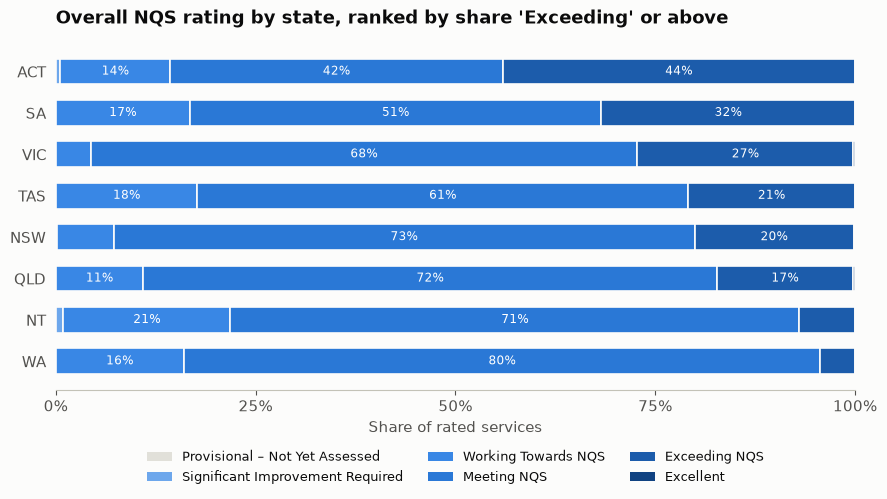

Best: ACT (44.1% Exceeding+)
Worst: WA (4.3% Exceeding+)


In [9]:

rated = df[df["State"].notna()].copy()
rated["OverallRating"] = rated["OverallRating"].astype(str)
props = (
    rated.groupby("State")["OverallRating"].value_counts(normalize=True)
    .unstack(fill_value=0).reindex(columns=RATING_ORDER, fill_value=0)
)
props["_score"] = props["Exceeding NQS"] + props["Excellent"]
props = props.sort_values("_score", ascending=False).drop(columns="_score")

fig, ax = plt.subplots(figsize=(9, 5.2))
stacked_bar(ax, props, RATING_ORDER, RATING_COLORS)
ax.set_title("Overall NQS rating by state, ranked by share 'Exceeding' or above",
             fontsize=13, fontweight="bold", color=INK_PRIMARY, loc="left", pad=14)
ax.set_xlabel("Share of rated services")
handles = [Patch(facecolor=RATING_COLORS[c], label=c) for c in RATING_ORDER]
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=3, frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "01_rating_by_state.png", dpi=200)
plt.show()

best, worst = props.index[0], props.index[-1]
print(f"Best: {best} ({(props.loc[best,'Exceeding NQS']+props.loc[best,'Excellent'])*100:.1f}% Exceeding+)")
print(f"Worst: {worst} ({(props.loc[worst,'Exceeding NQS']+props.loc[worst,'Excellent'])*100:.1f}% Exceeding+)")



## 5. Chart 2 — NQS rating by primary service type


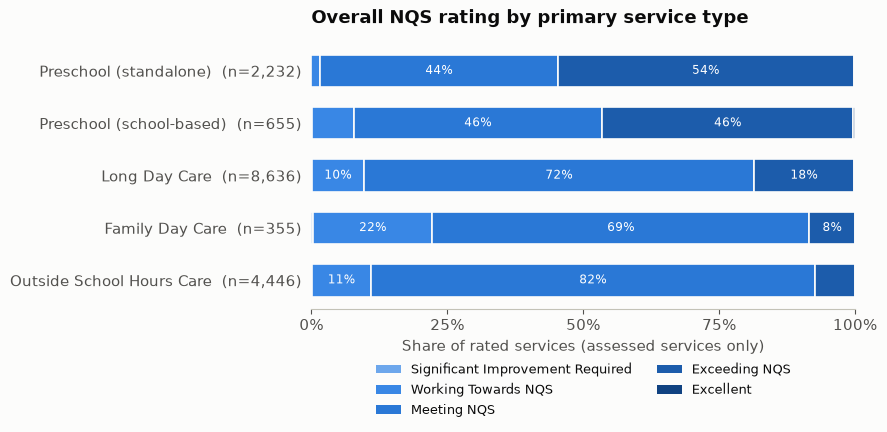

In [10]:

d = df[df["PrimaryServiceType"] != "Other"].copy()  # 3 services, not a meaningful group
d = d[d["OverallRating"].notna()]
d["OverallRating"] = d["OverallRating"].astype(str)
d = d[d["OverallRating"] != NOT_YET_ASSESSED]

props2 = (
    d.groupby("PrimaryServiceType")["OverallRating"].value_counts(normalize=True)
    .unstack(fill_value=0).reindex(columns=RATING_ORDER_SUBSTANTIVE, fill_value=0)
)
counts = d["PrimaryServiceType"].value_counts()
props2["_score"] = props2["Exceeding NQS"] + props2["Excellent"]
props2 = props2.sort_values("_score", ascending=False).drop(columns="_score")
props2.index = [f"{i}  (n={counts[i]:,})" for i in props2.index]

fig, ax = plt.subplots(figsize=(9, 4.6))
stacked_bar(ax, props2, RATING_ORDER_SUBSTANTIVE, RATING_COLORS)
ax.set_title("Overall NQS rating by primary service type", fontsize=13, fontweight="bold",
             color=INK_PRIMARY, loc="left", pad=14)
ax.set_xlabel("Share of rated services (assessed services only)")
handles = [Patch(facecolor=RATING_COLORS[c], label=c) for c in RATING_ORDER_SUBSTANTIVE]
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2, frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_rating_by_service_type.png", dpi=200)
plt.show()



## 6. Chart 3 — Which Quality Area drags each state down?

**Business question:** a low overall rating is made of seven component scores — which one should each state's regulator prioritise for support?


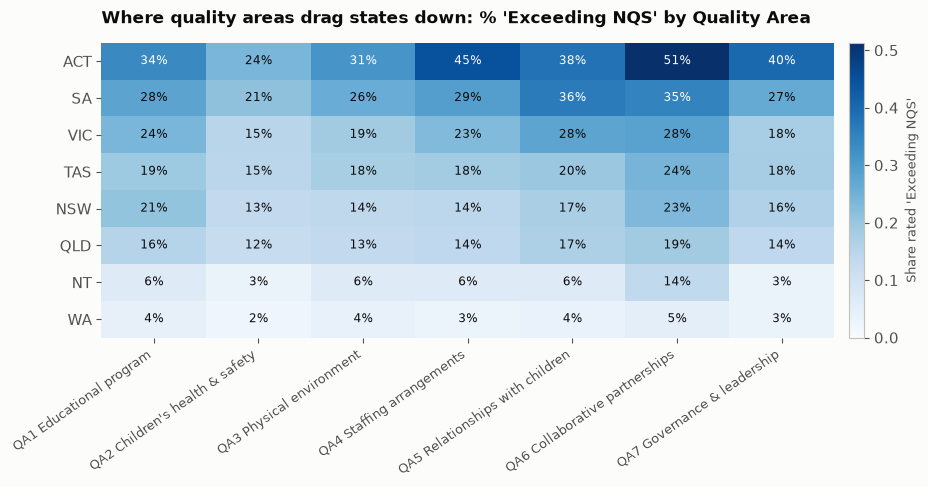

Weakest area nationally: QA2 Children's health & safety
Strongest area nationally: QA6 Collaborative partnerships


In [11]:

d3 = df[df["State"].notna()].copy()
qa_cols = list(QUALITY_AREA_LABELS.keys())
rows = []
for state, g in d3.groupby("State"):
    row = {}
    for col in qa_cols:
        s = g[col].astype(str)
        s = s[(s != "nan") & (s != NOT_YET_ASSESSED)]
        row[QUALITY_AREA_LABELS[col]] = (s == "Exceeding NQS").mean() if len(s) else np.nan
    rows.append(pd.Series(row, name=state))
heat = pd.DataFrame(rows)
heat = heat.loc[heat.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(9.5, 5))
im = ax.imshow(heat.values, cmap="Blues", vmin=0, vmax=heat.values.max(), aspect="auto")
ax.set_xticks(range(len(heat.columns))); ax.set_xticklabels(heat.columns, rotation=35, ha="right", fontsize=9)
ax.set_yticks(range(len(heat.index))); ax.set_yticklabels(heat.index)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.values[i, j]
        ax.text(j, i, f"{v:.0%}", ha="center", va="center", fontsize=8.5,
                color="white" if v > heat.values.max() * 0.6 else INK_PRIMARY)
for spine in ax.spines.values():
    spine.set_visible(False)
cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("Share rated 'Exceeding NQS'", color=INK_SECONDARY, fontsize=9)
ax.set_title("Where quality areas drag states down: % 'Exceeding NQS' by Quality Area",
             fontsize=12.5, fontweight="bold", color=INK_PRIMARY, loc="left", pad=14)
fig.tight_layout()
fig.savefig(FIG_DIR / "03_quality_area_heatmap.png", dpi=200)
plt.show()

print("Weakest area nationally:", heat.mean(axis=0).idxmin())
print("Strongest area nationally:", heat.mean(axis=0).idxmax())



## 7. Chart 4 (spatial) — Services across Australia by rating

Basemap: simplified Australian state boundaries from [rowanhogan/australian-states](https://github.com/rowanhogan/australian-states) (public GitHub repo derived from ABS boundaries) — used only for visual context, not for any statistical join.


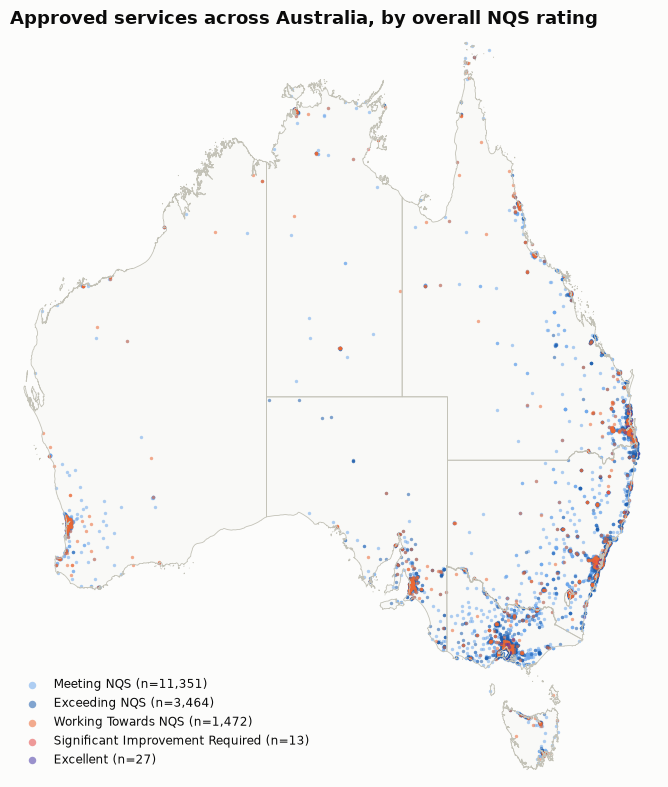

In [12]:

d4 = df[df["lon"].notna() & df["lat"].notna() & ~df["geocode_suspect"]].copy()
d4["OverallRating"] = d4["OverallRating"].astype(str)
tier_colors = {
    "Significant Improvement Required": CAT["red"],
    "Working Towards NQS": CAT["orange"],
    "Meeting NQS": SEQ_BLUE[2],
    "Exceeding NQS": SEQ_BLUE[5],
    "Excellent": CAT["violet"],
}
states = gpd.read_file(AU_STATES_GEOJSON)

fig, ax = plt.subplots(figsize=(9, 8))
states.boundary.plot(ax=ax, color=BASELINE, linewidth=0.6)
states.plot(ax=ax, color="#f9f9f7", edgecolor="none", zorder=0)

for tier in ["Meeting NQS", "Exceeding NQS", "Working Towards NQS", "Significant Improvement Required", "Excellent"]:
    sub = d4[d4["OverallRating"] == tier]
    if len(sub) == 0:
        continue
    ax.scatter(sub["lon"], sub["lat"], s=6, alpha=0.55, linewidths=0, color=tier_colors[tier],
               label=f"{tier} (n={len(sub):,})")

ax.set_xlim(112, 155); ax.set_ylim(-44, -9); ax.set_aspect(1.4)
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title("Approved services across Australia, by overall NQS rating",
             fontsize=13, fontweight="bold", color=INK_PRIMARY, loc="left", pad=10)
ax.legend(loc="lower left", frameon=False, fontsize=8.5, markerscale=2.2)
fig.tight_layout()
fig.savefig(FIG_DIR / "04_spatial_ratings_map.png", dpi=200)
plt.show()



## 8. Chart 5 — Does transport proximity predict quality?

**Business question:** should ACECQA or transport planners treat "near a train station" as a proxy for service quality? Torres Strait Island / very remote services (>100km from a station — genuine, not a data error, see the spatial map above) are excluded here only, since at national scale they'd compress every other distance bin onto a single pixel.


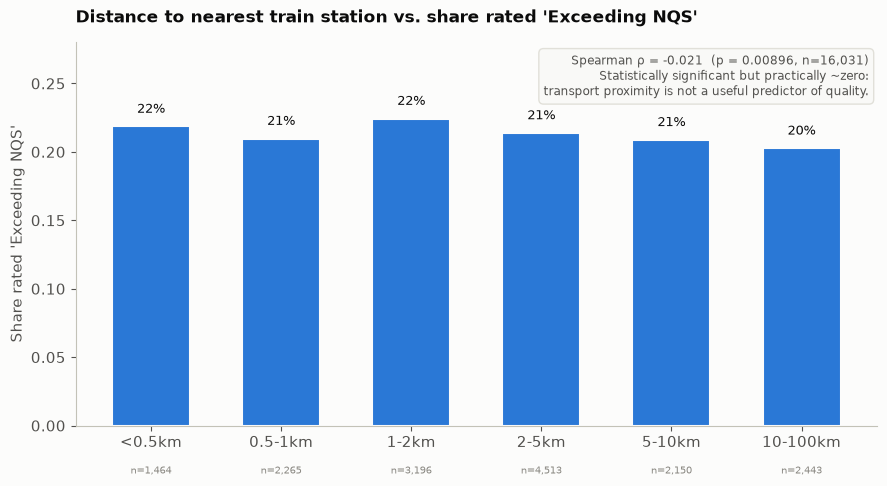

Spearman rho = -0.0206, p = 0.00896, n = 16,031
Excluded as very-remote outliers (>100km): 296


In [13]:

idx = rated_only(df["OverallRating"].dropna()).index
sub = df.loc[idx].copy()
sub["rating_code"] = sub["OverallRating"].astype(str).map({v: i for i, v in enumerate(RATING_ORDER_SUBSTANTIVE)})
sub_clean = sub[~sub["train_dist_outlier"]].copy()
n_excluded = int(sub["train_dist_outlier"].sum())

bins = [0, 0.5, 1, 2, 5, 10, 100]
labels = ["<0.5km", "0.5-1km", "1-2km", "2-5km", "5-10km", "10-100km"]
sub_clean["dist_bin"] = pd.cut(sub_clean["DistanceToTrainStation_km"], bins=bins, labels=labels)
sub_clean["OverallRating"] = sub_clean["OverallRating"].astype(str)
props5 = sub_clean.groupby("dist_bin", observed=True)["OverallRating"].apply(lambda s: (s == "Exceeding NQS").mean())
counts5 = sub_clean["dist_bin"].value_counts().reindex(labels)

rho, pval = stats.spearmanr(sub_clean["DistanceToTrainStation_km"], sub_clean["rating_code"])

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, props5.reindex(labels).values, color=CAT["blue"], width=0.6, edgecolor=SURFACE, linewidth=1.5)
for bar, lbl in zip(bars, labels):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{bar.get_height():.0%}",
            ha="center", fontsize=9, color=INK_PRIMARY)
    ax.text(bar.get_x() + bar.get_width() / 2, -0.035, f"n={counts5[lbl]:,}", ha="center", fontsize=7.5, color=INK_MUTED)
ax.set_ylim(0, max(props5.max() * 1.25, 0.05))
ax.set_ylabel("Share rated 'Exceeding NQS'")
ax.set_title("Distance to nearest train station vs. share rated 'Exceeding NQS'",
             fontsize=12.5, fontweight="bold", color=INK_PRIMARY, loc="left", pad=14)
ax.text(0.99, 0.97, f"Spearman ρ = {rho:.3f}  (p = {pval:.3g}, n={len(sub_clean):,})\n"
                    "Statistically significant but practically ~zero:\ntransport proximity is not a useful predictor of quality.",
        transform=ax.transAxes, ha="right", va="top", fontsize=8.5, color=INK_SECONDARY,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="#f9f9f7", edgecolor=GRIDLINE))
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color(BASELINE); ax.spines["bottom"].set_color(BASELINE)
fig.tight_layout()
fig.savefig(FIG_DIR / "05_transport_vs_quality.png", dpi=200)
plt.show()

print(f"Spearman rho = {rho:.4f}, p = {pval:.3g}, n = {len(sub_clean):,}")
print(f"Excluded as very-remote outliers (>100km): {n_excluded}")



## 9. Summary for the presentation

- **State spread is large**: ACT has the highest share of services rated "Exceeding NQS" or above, WA the lowest — a wide gap between regulatory jurisdictions applying the same National Law.
- **QA2 (Children's health & safety)** is the weakest Quality Area nationally; **QA6 (Collaborative partnerships)** the strongest — a concrete, area-specific lever for underperforming states rather than a vague "improve quality" message.
- **Transport proximity does not predict quality** (Spearman ρ ≈ -0.02, negligible despite statistical significance at this sample size) — a useful null result: don't treat transport access as a quality signal.
- 10 rows were dropped as unrecoverable geocoding failures (no address data at all); everything else was checked and kept.


In [14]:

summary = {
    "n_services_total": int(len(df)),
    "best_state": best,
    "worst_state": worst,
    "weakest_quality_area_nationally": heat.mean(axis=0).idxmin(),
    "strongest_quality_area_nationally": heat.mean(axis=0).idxmax(),
    "transport_quality_spearman_rho": round(float(rho), 4),
    "transport_quality_spearman_p": float(pval),
}
Path("outputs").mkdir(exist_ok=True)
Path("outputs/summary_stats.json").write_text(json.dumps(summary, indent=2, default=str))
summary


{'n_services_total': 17653,
 'best_state': 'ACT',
 'worst_state': 'WA',
 'weakest_quality_area_nationally': "QA2 Children's health & safety",
 'strongest_quality_area_nationally': 'QA6 Collaborative partnerships',
 'transport_quality_spearman_rho': -0.0206,
 'transport_quality_spearman_p': 0.008964483943696974}